# Agentic RAG using LangGraph
- Notebook by Adam Lang
- Date: 8-21-2026

# Overview
- In this notebook we will walk through implementing Agentic RAG in LangGraph

## Imports

In [3]:
## imports
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, END 
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document


## Set Environment Variables
- OpenAI models page: https://developers.openai.com/api/docs/models/all

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
## set OpenAI API key
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

## init models
llm = ChatOpenAI(model="gpt-4o-mini-2024-07-18", temperature=0)
embeddings = OpenAIEmbeddings()




In [6]:
## lets look at llm
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.15', 'langchain-openai': '1.5.1'}}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000024287CFF8D0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000242A5823190>, root_client=<openai.OpenAI object at 0x0000024287D8C910>, root_async_client=<openai.AsyncOpenAI object at 0x00000242A5822D50>, model_name='gpt-4o-mini-2024-07-18', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True, stream_chunk_timeout=120.0)

## State Definition

In [7]:
## create agent state
class AgentState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    needs_retrieval: bool

## Sample Documents and Vectorstore
- We will use sample text for this.

In [8]:
## sample document and vectorstore
sample_texts = [
    "LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.",
    "RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.",
    "Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.",
    "Agentic systems are AI systems that can take actions, make decisions, and interact with their environment autonomously. They often use planning and reasoning capabilities."
]
## convert into documents
documents=[Document(page_content=text) for text in sample_texts]

## create vector store in FAISS
vectorstore = FAISS.from_documents(documents, embeddings)

## create retriever
retriever = vectorstore.as_retriever(k=3)



## Agentic Functions
- Here we need to define the agentic-node definitions.
- This is pure Python programming, no model needed.

In [ ]:
## 1. decide retrieval (agent)
def decide_retrieval(state: AgentState) -> AgentState:
    """
    Decide if we need to retrieve documents based on the question. 

    """
    ## input question to system
    question = state["question"]

    ## simple heuristic: if question contains certain keywords --> retrieve
    retrieval_keywords = ["what", "how", "explain", "describe", "tell me"]
    needs_retrieval = any(keyword in question.lower() for keyword in retrieval_keywords)

    return {**state, "needs_retrieval": needs_retrieval}

In [10]:
## 2. retrieve documents (agent)
def retrieve_documents(state: AgentState) -> AgentState:
    """
    Retrieve relevant documents based on the question.
    """
    question = state["question"]
    documents = retriever.invoke(question)

    return {**state, "documents": documents}


In [11]:
## 3. Generate Answer
def generate_answer(state: AgentState) -> AgentState:
    """

    Generate an answer using the retrieved documents or direct response
    """
    question = state["question"]
    documents = state.get("documents", [])

    ## if there are documents present -- setup prompt
    if documents:
        # RAG approach: use documents as context
        context = "\n\n".join([doc.page_content for doc in documents])
        prompt = f"""Based on the following context, answer the question

Context:
{context}

Question: {question}

Answer:""" 
    else:
        ## Generate a Direct response without retrieval
        prompt = f"Answer the following question: {question}"

    ## generate response from LLM
    response = llm.invoke(prompt)
    answer = response.content

    return {**state, "answer": answer}

## Agent Conditional Logic

In [12]:
## conditional logic functions
def should_retrieve(state: AgentState) -> str:
    """
    Determine the next step based on retrieval decision
    """
    ## define logic here
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

## Build the Graph
- now we can build the full graph

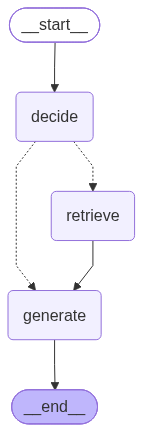

In [13]:
## 1. create the State Graph
workflow = StateGraph(AgentState)

## 2. Add nodes
workflow.add_node("decide", decide_retrieval)
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("generate", generate_answer)

## 3. set graph entry point
workflow.set_entry_point("decide")

## 4. Add conditional edges to graph
workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve": "retrieve",
        "generate": "generate",
    }
)

## 5. Add edges to graph
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

## 6. Compile graph
app = workflow.compile()
app


## Test Agentic System

In [14]:
## function to ask query
def ask_question(question: str): 
    """
    Helper function to ask a question and get an answer.
    """
    ## initial state
    initial_state = {
        "question": question,
        "documents": [],
        "answer": "",
        "needs_retrieval": False,
    }

    ## invoke app for result
    result = app.invoke(initial_state)
    return result





In [ ]:
## test question 1
question_1 = "What is LangGraph and what is it used for?"
result_1 = ask_question(question_1)
result_1

{'question': 'What is LangGraph and what is it used for?',
 'documents': [Document(id='cbf809cb-402c-44f9-ac52-c5c27d2234ea', metadata={}, page_content='LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.'),
  Document(id='7e6c5187-f2f4-4574-b45d-5347b47f0116', metadata={}, page_content='Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.'),
  Document(id='1026686a-5ae8-4c53-994a-a0c3a2805f08', metadata={}, page_content='RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.'),
  Document(id='b5947df8-e7af-444a-88ea-497981e5043a', metadata={}, page

In [16]:
## test question 2
question_2 = "How does RAG work?"
result2 = ask_question(question_2)

## show answer
print(f"Question: {question_2}")
print(f"Retrieved documents: {len(result2['documents'])}")
print(f"Answer: {result2['answer']}")
print("\n" + "="*50 + "\n")

Question: How does RAG work?
Retrieved documents: 4
Answer: RAG (Retrieval-Augmented Generation) works by combining two key processes: information retrieval and text generation. First, it retrieves relevant documents or pieces of information from a database based on a user's query. This retrieval process often utilizes vector databases, which store high-dimensional vectors and allow for efficient similarity searches to find documents that are semantically related to the query.

Once the relevant documents are retrieved, RAG uses this contextual information to generate more accurate and informed responses. The integration of retrieved content helps enhance the quality of the generated text, making it more relevant and contextually appropriate for the user's needs. This approach leverages the strengths of both retrieval and generation, resulting in a more effective and responsive AI system.


